# A) Vorbereitung

Notwendige Packages

In [1]:
import os
import glob
import pandas as pd
from lxml import etree as ET
from collections import Counter



## Datenset einlesen


Dafür muss sich das Datset im selben lokalen Ordner befinden, wie das Notebook.

In [2]:
rentsall_korrektur_df = pd.read_csv('rentsall_korrektur_df.csv')

In [3]:
# 1. Alle einzigartigen Kategorien alphabetisch sortiert anzeigen
unique_causes = sorted(rentsall_korrektur_df['cause'].unique().astype(str))
print("Vorhandene Kategorien in 'cause':")
print(unique_causes)

# 2. Bonus: Direkt anzeigen, wie oft jede Kategorie vorkommt (Häufigkeit)
print("\nAnzahl der Einträge pro Kategorie:")
print(rentsall_korrektur_df['cause'].value_counts())

Vorhandene Kategorien in 'cause':
[np.str_('2.0 UNKNOWN'), np.str_('Alle 4 Fronfasten'), np.str_('Bodenzins'), np.str_('Ehrschatz'), np.str_('Eigenschaft'), np.str_('Fasnachtshühner'), np.str_('Hauptgut'), np.str_('Jahrzeitenzins'), np.str_('Rente'), np.str_('Rentenkauf'), np.str_('Selgerete'), np.str_('UNKNOWN'), np.str_('UNKNOWN: Angabe/Abgabe'), np.str_('UNKNOWN: Angaria'), np.str_('UNKNOWN: Erbschaft'), np.str_('UNKNOWN: Farzit'), np.str_('UNKNOWN: Fastnacht'), np.str_('UNKNOWN: Honorar'), np.str_('UNKNOWN: Lehen'), np.str_('UNKNOWN: Martini'), np.str_('UNKNOWN: Morgengabe'), np.str_('UNKNOWN: Sache'), np.str_('UNKNOWN: Selbuch'), np.str_('UNKNOWN: Time/Feast (Fasnacht)'), np.str_('UNKNOWN: Wasserrecht'), np.str_('UNKNOWN: Zins'), np.str_('UNKNOWN: Zunft'), np.str_('UNKNOWN: inheritance'), np.str_('UNKNOWN: interest'), np.str_('UNKNOWN: lifetime'), np.str_('UNKNOWN: payment'), np.str_('Weingelt'), np.str_('Weisung'), np.str_('nan'), np.str_('not_mentioned'), np.str_('unk unk'), np.

In [4]:
# Zeigt die Datentypen aller Spalten
print(rentsall_korrektur_df.dtypes)

collection_id              object
collection_street          object
collection_house           object
collection_coord_x        float64
collection_coord_y        float64
id                          int64
dossier                    object
pages                      object
year                      float64
text                       object
language                   object
imagelinks                 object
source                     object
db_id                      object
file                       object
property_purchase_case     object
dues_case                  object
beneficiary                object
claimantOrg                object
interest                   object
interest_norm              object
interest_pd               float64
cause                      object
redeemable                 object
redeemable_amount          object
redeemable_amount_norm     object
redeemable_amount_pd       object
dues_text                  object
renteabloesig              object
hauptgutabloes

## Zusammensetzung bestimmter Causes

- Renten

Das Festhalten des exakten Zeitpunktes eines Kaufes einer Rente ist für meine Analyse nicht wichtig, weil wir das exakte Ende nicht bestimmen können.
Der Vergleich zwischen Renten und anderen Zinsarten ist wichtiger. Deswegen vereinheitliche ich die die Treffer Renten und Rentenkauf

In [5]:
# Alle exakten Treffer von "Rentenkauf" in "Rente" umbenennen

rentsall_korrektur_df['cause'] = rentsall_korrektur_df['cause'].replace('Rentenkauf', 'Rente')

# Kurzer Check: Wie viele "Rente" Einträge gibt es jetzt?
print(rentsall_korrektur_df['cause'].value_counts().get('Rente', 0))

4587


- Eigenschaften

Bodenzinsen sind grundsätzlich Eigenschaftszinsen, respektive Eigenschaftszinsen sind meist Bestandteil der Bodenzinsen. Aus diesem Grund behandle ich Erwähnungen von Bodezinsen als Eigenschaftszinsen:

In [6]:
# Alle exakten Treffer von "Rente" in "Rentenkauf" umbenennen
rentsall_korrektur_df['cause'] = rentsall_korrektur_df['cause'].replace('Bodenzins', 'Eigenschaft')

# Kurzer Check: Wie viele "Rentenkauf" Einträge gibt es jetzt?
print(rentsall_korrektur_df['cause'].value_counts().get('Eigenschaft', 0))

4236


- Hauptgut

Es macht Sinn die Treffer der Hauptgüter als Hinweis auf eine vorhandene Rente zu verstehen. Deswegen können wir die Hauptgüter in Renten umwandeln. Das Hauptgut direkt zur Rente Umwandeln ist aber nur eine gute Idee, wenn die Werte in einer Analyse nicht berücksichtigt werden!

In [7]:
## Achtung ich zähle neu Hauptgut auch zu Rente für die Berechnung der Zeitspannen
# Alle exakten Treffer von "Rente" in "Rentenkauf" umbenennen
#rentsall_korrektur_df['cause'] = rentsall_korrektur_df['cause'].replace('Hauptgut', 'Rentenkauf')

# Kurzer Check: Wie viele "Rentenkauf" Einträge gibt es jetzt?
# print(rentsall_korrektur_df['cause'].value_counts().get('Rentenkauf', 0))


## Anpassung der Koordinaten 

(dauert eine Weile)

Vorbereitung für Transformation

In [8]:
from pyproj import Transformer

def transform_coords(x, y):
    transformer = Transformer.from_crs(2056, 4326)
    return transformer.transform(x, y)



Transformation

In [9]:
# Transform the coordinates of the search results.
def transform_coords(x, y):
    transformer = Transformer.from_crs(2056, 4326)
    return transformer.transform(x, y)
rentsall_korrektur_df['lat'], rentsall_korrektur_df['lon'] = zip(*rentsall_korrektur_df.apply(
    lambda row: transform_coords(row['collection_coord_x'], row['collection_coord_y']), axis=1
    ))
rentsall_korrektur_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
0,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,NaN,47.550546,7.593183
1,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,Frau Elsy Lutpoltin,47.550546,7.593183
2,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,70628,HGB_1_001_027,5,1421.0,gend ze kaufen Hauss am Steg von Westhusen\nun...,...,NaN,NaN,NaN,NaN,ist erb von der brudersch . zes . Johans uf Bu...,NaN,NaN,NaN,47.550546,7.593183
3,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,90559,HGB_1_001_027,6,1424.0,gend ze kaufen Henman Weyblinger der schnider\...,...,NaN,NaN,NaN,NaN,dem darab gand 4sh . u . och zem teil vor Henn...,NaN,NaN,dem,47.550546,7.593183
4,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,42268,HGB_1_001_027,9,1482.0,Burkhart Segenser Schultheis als Vogt ư Gwalth...,...,NaN,NaN,NaN,NaN,zinset von eig . 2sh . s . Joh . Brudi uf Burg...,NaN,NaN,NaN,47.550546,7.593183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18521,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18522,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18523,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575
18524,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575


In [10]:
rentsall_korrektur_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon
0,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,NaN,47.550546,7.593183
1,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,Frau Elsy Lutpoltin,47.550546,7.593183
2,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,70628,HGB_1_001_027,5,1421.0,gend ze kaufen Hauss am Steg von Westhusen\nun...,...,NaN,NaN,NaN,NaN,ist erb von der brudersch . zes . Johans uf Bu...,NaN,NaN,NaN,47.550546,7.593183
3,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,90559,HGB_1_001_027,6,1424.0,gend ze kaufen Henman Weyblinger der schnider\...,...,NaN,NaN,NaN,NaN,dem darab gand 4sh . u . och zem teil vor Henn...,NaN,NaN,dem,47.550546,7.593183
4,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,42268,HGB_1_001_027,9,1482.0,Burkhart Segenser Schultheis als Vogt ư Gwalth...,...,NaN,NaN,NaN,NaN,zinset von eig . 2sh . s . Joh . Brudi uf Burg...,NaN,NaN,NaN,47.550546,7.593183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18521,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18522,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708
18523,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575
18524,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575


# B) Analyse

## 1. Textsuche

Zum Durchsuchen des gesamten Textes einer Karteikarte nach einem beliebigen Begriff:

In [11]:
from rapidfuzz import fuzz

# Suchparameter
search_term = "vasnachthu"
threshold = 80

# Fuzzy-Match auf der gesamten Spalte "text"
rentsall_korrektur_df["fuzzy_score"] = rentsall_korrektur_df["text"].fillna("").apply(
    lambda x: fuzz.partial_ratio(search_term.lower(), x.lower())
)

# Nur Treffer mit Score >= 80 behalten
treffer_df = rentsall_korrektur_df[rentsall_korrektur_df["fuzzy_score"] >= threshold].copy()

# Ergebnis anzeigen
print(treffer_df[["text", "fuzzy_score"]])

                                                    text  fuzzy_score
93     Item do git ze kouffende Grede Fricker relta q...         80.0
94     Item do git ze kouffende Grede Fricker relta q...         80.0
95     Item do git ze kouffende Grede Fricker relta q...         80.0
96     gend ze kaufen Uhlin Hauselman der gerwer\nCla...         90.0
97     gend ze kaufen Uhlin Hauselman der gerwer\nCla...         90.0
...                                                  ...          ...
17466  Schultheissen Urkunde.\nHeinrich Engelman der ...         80.0
17467  Schultheissen Urkunde.\nHeinrich Engelman der ...         80.0
17612  gend ze kaufen Mr Hans Mülhuser der messer¬\ns...         90.0
17992  Junker Ottman zem houpt vom Rinfelden verkauft...         80.0
18078  verschreiben sich gegen sant Mar¬\ntin Josen I...         80.0

[393 rows x 2 columns]


In [12]:
treffer_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon,fuzzy_score
93,HGB_1_002_046,Aeschenvorstadt,Aeschenvorstadt 37,2.611637e+06,1.266909e+06,1807,HGB_1_002_046,3,1413.0,Item do git ze kouffende Grede Fricker relta q...,...,NaN,NaN,NaN,der da von gangent 13 zinsph ze den 4 fronvast...,NaN,NaN,der,47.552793,7.593218,80.0
94,HGB_1_002_046,Aeschenvorstadt,Aeschenvorstadt 37,2.611637e+06,1.266909e+06,1807,HGB_1_002_046,3,1413.0,Item do git ze kouffende Grede Fricker relta q...,...,NaN,NaN,NaN,der da von gangent 13 zinsph ze den 4 fronvast...,NaN,NaN,der,47.552793,7.593218,80.0
95,HGB_1_002_046,Aeschenvorstadt,Aeschenvorstadt 37,2.611637e+06,1.266909e+06,1807,HGB_1_002_046,3,1413.0,Item do git ze kouffende Grede Fricker relta q...,...,NaN,NaN,NaN,der da von gangent 13 zinsph ze den 4 fronvast...,NaN,NaN,der,47.552793,7.593218,80.0
96,HGB_1_002_046,Aeschenvorstadt,Aeschenvorstadt 37,2.611637e+06,1.266909e+06,4091,HGB_1_002_046,8,1437.0,gend ze kaufen Uhlin Hauselman der gerwer\nCla...,...,NaN,NaN,NaN,zinset voneig . der brudersch uf Burg 12 1 / 2...,NaN,NaN,NaN,47.552793,7.593218,90.0
97,HGB_1_002_046,Aeschenvorstadt,Aeschenvorstadt 37,2.611637e+06,1.266909e+06,4091,HGB_1_002_046,8,1437.0,gend ze kaufen Uhlin Hauselman der gerwer\nCla...,...,NaN,NaN,NaN,zinset voneig . der brudersch uf Burg 12 1 / 2...,NaN,NaN,NaN,47.552793,7.593218,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17466,HGB_1_168_063,Riehentorstrasse / Riehenthorstrasse,"Riehentorstrasse 14, 16",2.611833e+06,1.267620e+06,102104,HGB_1_168_063,11,1487.0,Schultheissen Urkunde.\nHeinrich Engelman der ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.559185,7.595848,80.0
17467,HGB_1_168_063,Riehentorstrasse / Riehenthorstrasse,"Riehentorstrasse 14, 16",2.611833e+06,1.267620e+06,102104,HGB_1_168_063,11,1487.0,Schultheissen Urkunde.\nHeinrich Engelman der ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.559185,7.595848,80.0
17612,HGB_1_181_013,Schifflände,Schifflände Theil von 3,2.611272e+06,1.267674e+06,97739,HGB_1_181_013,4,1438.0,gend ze kaufen Mr Hans Mülhuser der messer¬\ns...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.559683,7.588384,90.0
17992,HGB_1_197_050,Spalenvorstadt,Spalenvorstadt 31,2.610798e+06,1.267438e+06,89480,HGB_1_197_050,6,1419.0,Junker Ottman zem houpt vom Rinfelden verkauft...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.557568,7.582088,80.0


Jetzt noch inklusive Markierung der entsprechenden Textstellen:

In [13]:
from rapidfuzz import fuzz, process
from IPython.display import display, HTML

# Suchparameter
search_term = "vasnachthu"
threshold = 80

def highlight_fuzzy_match(text, search_term, threshold=80):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Alle möglichen Teilstrings der Länge des Suchbegriffs vergleichen
    best_score = 0
    best_match = ""
    best_start = 0
    
    search_len = len(search_term)

    for i in range(len(text) - search_len + 1):
        substring = text[i:i + search_len]
        score = fuzz.ratio(search_term.lower(), substring.lower())
        
        if score > best_score:
            best_score = score
            best_match = substring
            best_start = i

    # Falls der Treffer nicht gut genug ist, nichts markieren
    if best_score < threshold:
        return text
    
    # HTML-Markierung erzeugen
    highlighted = (
        text[:best_start]
        + f"<mark style='background-color: yellow'>{best_match}</mark>"
        + text[best_start + len(best_match):]
    )
    
    return highlighted


# Fuzzy-Score berechnen
rentsall_korrektur_df["fuzzy_score"] = rentsall_korrektur_df["text"].fillna("").apply(
    lambda x: fuzz.partial_ratio(search_term.lower(), str(x).lower())
)

# Treffer filtern
treffer_df = rentsall_korrektur_df[rentsall_korrektur_df["fuzzy_score"] >= threshold].copy()

# Markierte Version erzeugen
treffer_df["text_highlighted"] = treffer_df["text"].apply(
    lambda x: highlight_fuzzy_match(x, search_term, threshold)
)

# Ausgabe im Jupyter Notebook
display(
    HTML(
        treffer_df[["text_highlighted", "fuzzy_score"]]
        .to_html(escape=False, index=False)
    )
)

text_highlighted,fuzzy_score
"Item do git ze kouffende Grede Fricker relta qu\nJoh de Winchen (sic) anifabri et Greda Fricke¬\nrin relta qud Jacobi Frickli, Joh Hugoltz nomm\nprocurator dnor marastre et guetg mon ire\nSchöntal ardmis sti under daz huse und hof¬\nstat genant Wagemberg gelegen ze Basel in der\nstat zwüschent den huser zem Gutterlin und\nHenman Hirsingers des kesslers ist erbe von\nder bruderscht sant Joh cappelle uff Burg ze\nBasel der da von gangent 13 zinsph ze den\n4 fronvasten einen ring brotes uff sant\nMartz tage und ein hun ze vasnacht ze wi¬\nsung und 2ß ze erschatz, item über densel¬\nben zinse ete gangent 6 ȡ der ege müntz\neinem lutpriester ze sant Ulr, umb 110 gul.\nGerichtsbuch der mehrern Stadt A 10.",80.000000
"Item do git ze kouffende Grede Fricker relta qu\nJoh de Winchen (sic) anifabri et Greda Fricke¬\nrin relta qud Jacobi Frickli, Joh Hugoltz nomm\nprocurator dnor marastre et guetg mon ire\nSchöntal ardmis sti under daz huse und hof¬\nstat genant Wagemberg gelegen ze Basel in der\nstat zwüschent den huser zem Gutterlin und\nHenman Hirsingers des kesslers ist erbe von\nder bruderscht sant Joh cappelle uff Burg ze\nBasel der da von gangent 13 zinsph ze den\n4 fronvasten einen ring brotes uff sant\nMartz tage und ein hun ze vasnacht ze wi¬\nsung und 2ß ze erschatz, item über densel¬\nben zinse ete gangent 6 ȡ der ege müntz\neinem lutpriester ze sant Ulr, umb 110 gul.\nGerichtsbuch der mehrern Stadt A 10.",80.000000
"Item do git ze kouffende Grede Fricker relta qu\nJoh de Winchen (sic) anifabri et Greda Fricke¬\nrin relta qud Jacobi Frickli, Joh Hugoltz nomm\nprocurator dnor marastre et guetg mon ire\nSchöntal ardmis sti under daz huse und hof¬\nstat genant Wagemberg gelegen ze Basel in der\nstat zwüschent den huser zem Gutterlin und\nHenman Hirsingers des kesslers ist erbe von\nder bruderscht sant Joh cappelle uff Burg ze\nBasel der da von gangent 13 zinsph ze den\n4 fronvasten einen ring brotes uff sant\nMartz tage und ein hun ze vasnacht ze wi¬\nsung und 2ß ze erschatz, item über densel¬\nben zinse ete gangent 6 ȡ der ege müntz\neinem lutpriester ze sant Ulr, umb 110 gul.\nGerichtsbuch der mehrern Stadt A 10.",80.000000
"gend ze kaufen Uhlin Hauselman der gerwer\nClaus Heuselman sin bruder der Rebman u Claren\nMeych Elsin Henselman swesterman u. v. d m.\nan Conezen Kupferwurm den Kupferschmid,\ndaz Hus & Hofstatt genant Wagenberg mit dem\ngarten derhinder, so gelegen ist ze Eschemerthor\nzwüschen den hüsern zem gutterlin u. Ressenegg\nzinset voneig. der brudersch uf Burg 12 1/2sh.\nt vasnacht hun u tring brot wisung, u. 2sh erschatz,\nu denne gand daraben dem hitptuster silich 6 dn\nvon jarziten, um 250 fl.",90.000000
"gend ze kaufen Uhlin Hauselman der gerwer\nClaus Heuselman sin bruder der Rebman u Claren\nMeych Elsin Henselman swesterman u. v. d m.\nan Conezen Kupferwurm den Kupferschmid,\ndaz Hus & Hofstatt genant Wagenberg mit dem\ngarten derhinder, so gelegen ist ze Eschemerthor\nzwüschen den hüsern zem gutterlin u. Ressenegg\nzinset voneig. der brudersch uf Burg 12 1/2sh.\nt vasnacht hun u tring brot wisung, u. 2sh erschatz,\nu denne gand daraben dem hitptuster silich 6 dn\nvon jarziten, um 250 fl.",90.000000
"gend ze kaufen Uhlin Hauselman der gerwer\nClaus Heuselman sin bruder der Rebman u Claren\nMeych Elsin Henselman swesterman u. v. d m.\nan Conezen Kupferwurm den Kupferschmid,\ndaz Hus & Hofstatt genant Wagenberg mit dem\ngarten derhinder, so gelegen ist ze Eschemerthor\nzwüschen den hüsern zem gutterlin u. Ressenegg\nzinset voneig. der brudersch uf Burg 12 1/2sh.\nt vasnacht hun u tring brot wisung, u. 2sh erschatz,\nu denne gand daraben dem hitptuster silich 6 dn\nvon jarziten, um 250 fl.",90.000000
"gend ze kaufen Uhlin Hauselman der gerwer\nClaus Heuselman sin bruder der Rebman u Claren\nMeych Elsin Henselman swesterman u. v. d m.\nan Conezen Kupferwurm den Kupferschmid,\ndaz Hus & Hofstatt genant Wagenberg mit dem\ngarten derhinder, so gelegen ist ze Eschemerthor\nzwüschen de

## 2. Auszählung Zinsarten Institutionen

Separates DF für die Institutionen herstellen:

In [14]:
# Alle Zeilen entfernen, die einen Eintrag in beneficiary_per haben
Institotal_df = rentsall_korrektur_df[
    rentsall_korrektur_df["beneficiary_per"].isna()
    | (rentsall_korrektur_df["beneficiary_per"].astype(str).str.strip() == "")
].copy()

In [15]:
Institotal_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon,fuzzy_score
0,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,NaN,47.550546,7.593183,50.0
2,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,70628,HGB_1_001_027,5,1421.0,gend ze kaufen Hauss am Steg von Westhusen\nun...,...,NaN,NaN,NaN,ist erb von der brudersch . zes . Johans uf Bu...,NaN,NaN,NaN,47.550546,7.593183,50.0
4,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,42268,HGB_1_001_027,9,1482.0,Burkhart Segenser Schultheis als Vogt ư Gwalth...,...,NaN,NaN,NaN,zinset von eig . 2sh . s . Joh . Brudi uf Burg...,NaN,NaN,NaN,47.550546,7.593183,50.0
5,HGB_1_001_034,Aeschengraben,Aeschengraben 30,2.611587e+06,1.266613e+06,15842,HGB_1_001_034,3,1482.0,Meister Heinrich Clingenberg verkauft an Mr. H...,...,NaN,NaN,NaN,"zinset 8 sh . zu Gnadental , sonstfrei",NaN,NaN,NaN,47.550137,7.592548,50.0
7,HGB_1_001_038,Aeschengraben,Aeschengraben 34,2.611568e+06,1.266590e+06,94917,HGB_1_001_038,4,1487.0,Klaus Kesler von Nuwenburg ư seine Frau Elsin\...,...,NaN,NaN,NaN,zinset von eig . 2 1 / 2 sh . Lienhart Gernler...,NaN,NaN,NaN,47.549926,7.592295,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18521,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708,40.0
18522,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708,40.0
18523,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575,50.0
18524,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575,50.0


Auszählung der Zinsarten aller Institutionen:

In [16]:
# Häufigkeit aller Werte in der Spalte "cause"
cause_counts = Institotal_df["cause"].value_counts()

print(cause_counts)

cause
Eigenschaft               3803
Rente                     2278
Ehrschatz                 1562
Weisung                   1387
Jahrzeitenzins             209
Selgerete                  178
UNKNOWN                    150
UNKNOWN: Erbschaft          87
not_mentioned               33
Hauptgut                    21
UNKNOWN: Fastnacht           5
UNKNOWN: inheritance         4
UNKNOWN: Angaria             3
UNKNOWN: Zins                2
UNKNOWN: Wasserrecht         2
UNKNOWN: Farzit              2
von den Höwen                1
UNKNOWN: Angabe/Abgabe       1
2.0 UNKNOWN                  1
Alle 4 Fronfasten            1
von Erbschaft                1
UNKNOWN: Zunft               1
Weingelt                     1
Fasnachtshühner              1
UNKNOWN: Honorar             1
UNKNOWN: Morgengabe          1
Name: count, dtype: int64


Eingrenzung der Auszählung auf die Zeitspanne 1400 - 1530

In [17]:
yearmin = 1400
yearmax = 1530

# Jahr in Integer umwandeln
Institotal_df["year"] = Institotal_df["year"].astype(int)

# Zeitraum filtern
zinsen_personen_filtered_df = Institotal_df[
    (Institotal_df["year"] >= yearmin) &
    (Institotal_df["year"] <= yearmax)
]

# Häufigkeit aller Werte in der Spalte "cause"
cause_counts = zinsen_personen_filtered_df["cause"].value_counts()

print(cause_counts)

cause
Eigenschaft               3059
Rente                     1442
Ehrschatz                 1341
Weisung                   1190
Jahrzeitenzins             204
Selgerete                  176
UNKNOWN                    144
UNKNOWN: Erbschaft          87
not_mentioned               32
Hauptgut                     6
UNKNOWN: Fastnacht           5
UNKNOWN: inheritance         4
UNKNOWN: Angaria             3
UNKNOWN: Zins                2
UNKNOWN: Wasserrecht         2
UNKNOWN: Farzit              2
von den Höwen                1
UNKNOWN: Angabe/Abgabe       1
2.0 UNKNOWN                  1
Alle 4 Fronfasten            1
von Erbschaft                1
UNKNOWN: Zunft               1
Weingelt                     1
Fasnachtshühner              1
UNKNOWN: Honorar             1
UNKNOWN: Morgengabe          1
Name: count, dtype: int64


## 3. Auszählung Zinsarten Personen

Separates DF für die Institutionen herstellen:

In [18]:
# Nur Zeilen behalten, bei denen beneficiary_per nicht leer oder NaN ist
zinsen_personen_df = rentsall_korrektur_df[
    rentsall_korrektur_df["beneficiary_per"].notna()
    & (rentsall_korrektur_df["beneficiary_per"].astype(str).str.strip() != "")
].copy()

In [19]:
zinsen_personen_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon,fuzzy_score
1,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,Frau Elsy Lutpoltin,47.550546,7.593183,50.000000
3,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,90559,HGB_1_001_027,6,1424.0,gend ze kaufen Henman Weyblinger der schnider\...,...,NaN,NaN,NaN,dem darab gand 4sh . u . och zem teil vor Henn...,NaN,NaN,dem,47.550546,7.593183,50.000000
6,HGB_1_001_036,Aeschengraben,Aeschengraben 32,2.611581e+06,1.266602e+06,107464,HGB_1_001_036,4,1494.0,"Lienhart Gernler der seyler, verkauft an Ulric...",...,NaN,NaN,NaN,zinst von eig . dem obgl . Verkäufer 5sh . son...,NaN,NaN,dem obgl . Verkäufer,47.550036,7.592473,40.000000
9,HGB_1_001_038,Aeschengraben,Aeschengraben 34,2.611568e+06,1.266590e+06,13432,HGB_1_001_038,5,1492.0,"Jacob Sarrach der Mürer u seine Frau Elsy, ver...",...,NaN,NaN,NaN,zinst von eig . Lienhart Gernler 2 1 / 2sh . s...,NaN,NaN,Lienhart Gernler,47.549926,7.592295,40.000000
12,HGB_1_002_021,Aeschenvorstadt,Aeschenvorstadt 1,2.611578e+06,1.267024e+06,91404,HGB_1_002_021,5,1420.0,"Conrat der Wannenmacher, u. Gredanna\nsin ewir...",...,NaN,NaN,NaN,ist erb von den herren s . Lienh . denen man g...,NaN,NaN,Peter Altkilchs des Schumachers sel . frowen,47.553834,7.592436,60.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18495,HGB_1_227_077,Webergasse,Webergasse 40,2.611563e+06,1.267969e+06,3195,HGB_1_227_077,"13, 14",1421.0,Schultheissen Urkunde.\nBurgkli Reber der Rebm...,...,NaN,NaN,NaN,NaN,NaN,NaN,denen,47.562334,7.592261,58.823529
18498,HGB_1_227_077,Webergasse,Webergasse 40,2.611563e+06,1.267969e+06,23816,HGB_1_227_077,"3, 4",1410.0,"Item het zu koffende gen Heini Michelin,\net C...",...,NaN,NaN,NaN,NaN,NaN,NaN,Conrat Seg . wer,47.562334,7.592261,60.000000
18500,HGB_1_227_077,Webergasse,Webergasse 40,2.611563e+06,1.267969e+06,108291,HGB_1_227_077,9,1416.0,"Shultheissen Urkunde.\nCunrat Segwor, Burger z...",...,NaN,NaN,NaN,NaN,NaN,NaN,im,47.562334,7.592261,50.000000
18505,HGB_1_229_027,Weisse Gasse / Weissegasse,Weisse Gasse 4,2.611355e+06,1.267252e+06,8418,HGB_1_229_027,28,1501.0,"Thomas Swartz der Kartemmoler, u. seine Frau M...",...,NaN,NaN,NaN,NaN,NaN,NaN,Jacob Labahlins sel .,47.555889,7.589486,50.000000


Auszählung der Zinsarten aller Personen:

In [20]:
# Häufigkeit aller Werte in der Spalte "cause"
cause_counts = zinsen_personen_df["cause"].value_counts()

print(cause_counts)

cause
Rente                             2309
Eigenschaft                        433
Ehrschatz                          298
Weisung                            263
UNKNOWN                             37
UNKNOWN: Erbschaft                  19
Hauptgut                            16
not_mentioned                       11
Selgerete                            8
Jahrzeitenzins                       6
UNKNOWN: Lehen                       3
UNKNOWN: Zins                        2
UNKNOWN: payment                     1
UNKNOWN: Martini                     1
UNKNOWN: Fastnacht                   1
unk unk                              1
UNKNOWN: Time/Feast (Fasnacht)       1
UNKNOWN: interest                    1
UNKNOWN: lifetime                    1
UNKNOWN: Sache                       1
UNKNOWN: Selbuch                     1
Name: count, dtype: int64


Eingrenzung der Auszählung auf die Zeitspanne 1400 - 1530

In [21]:
yearmin = 1400
yearmax = 1530

# Jahr in Integer umwandeln
zinsen_personen_df["year"] = zinsen_personen_df["year"].astype(int)

# Zeitraum filtern
zinsen_personen_filtered_df = zinsen_personen_df[
    (zinsen_personen_df["year"] >= yearmin) &
    (zinsen_personen_df["year"] <= yearmax)
]

# Häufigkeit aller Werte in der Spalte "cause"
cause_counts = zinsen_personen_filtered_df["cause"].value_counts()

print(cause_counts)

cause
Rente                             1736
Eigenschaft                        397
Ehrschatz                          287
Weisung                            253
UNKNOWN                             36
UNKNOWN: Erbschaft                  18
not_mentioned                       10
Selgerete                            8
Jahrzeitenzins                       5
UNKNOWN: Lehen                       3
Hauptgut                             3
UNKNOWN: Zins                        2
UNKNOWN: Martini                     1
UNKNOWN: Fastnacht                   1
UNKNOWN: payment                     1
UNKNOWN: Time/Feast (Fasnacht)       1
UNKNOWN: interest                    1
UNKNOWN: lifetime                    1
UNKNOWN: Sache                       1
UNKNOWN: Selbuch                     1
Name: count, dtype: int64


In [22]:
zinsen_personen_filtered_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon,fuzzy_score
1,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,Frau Elsy Lutpoltin,47.550546,7.593183,50.000000
3,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,90559,HGB_1_001_027,6,1424,gend ze kaufen Henman Weyblinger der schnider\...,...,NaN,NaN,NaN,dem darab gand 4sh . u . och zem teil vor Henn...,NaN,NaN,dem,47.550546,7.593183,50.000000
6,HGB_1_001_036,Aeschengraben,Aeschengraben 32,2.611581e+06,1.266602e+06,107464,HGB_1_001_036,4,1494,"Lienhart Gernler der seyler, verkauft an Ulric...",...,NaN,NaN,NaN,zinst von eig . dem obgl . Verkäufer 5sh . son...,NaN,NaN,dem obgl . Verkäufer,47.550036,7.592473,40.000000
9,HGB_1_001_038,Aeschengraben,Aeschengraben 34,2.611568e+06,1.266590e+06,13432,HGB_1_001_038,5,1492,"Jacob Sarrach der Mürer u seine Frau Elsy, ver...",...,NaN,NaN,NaN,zinst von eig . Lienhart Gernler 2 1 / 2sh . s...,NaN,NaN,Lienhart Gernler,47.549926,7.592295,40.000000
12,HGB_1_002_021,Aeschenvorstadt,Aeschenvorstadt 1,2.611578e+06,1.267024e+06,91404,HGB_1_002_021,5,1420,"Conrat der Wannenmacher, u. Gredanna\nsin ewir...",...,NaN,NaN,NaN,ist erb von den herren s . Lienh . denen man g...,NaN,NaN,Peter Altkilchs des Schumachers sel . frowen,47.553834,7.592436,60.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18494,HGB_1_227_077,Webergasse,Webergasse 40,2.611563e+06,1.267969e+06,3195,HGB_1_227_077,"13, 14",1421,Schultheissen Urkunde.\nBurgkli Reber der Rebm...,...,NaN,NaN,NaN,NaN,NaN,NaN,denen,47.562334,7.592261,58.823529
18495,HGB_1_227_077,Webergasse,Webergasse 40,2.611563e+06,1.267969e+06,3195,HGB_1_227_077,"13, 14",1421,Schultheissen Urkunde.\nBurgkli Reber der Rebm...,...,NaN,NaN,NaN,NaN,NaN,NaN,denen,47.562334,7.592261,58.823529
18498,HGB_1_227_077,Webergasse,Webergasse 40,2.611563e+06,1.267969e+06,23816,HGB_1_227_077,"3, 4",1410,"Item het zu koffende gen Heini Michelin,\net C...",...,NaN,NaN,NaN,NaN,NaN,NaN,Conrat Seg . wer,47.562334,7.592261,60.000000
18500,HGB_1_227_077,Webergasse,Webergasse 40,2.611563e+06,1.267969e+06,108291,HGB_1_227_077,9,1416,"Shultheissen Urkunde.\nCunrat Segwor, Burger z...",...,NaN,NaN,NaN,NaN,NaN,NaN,im,47.562334,7.592261,50.000000


# Genaue Betrachtung der Eigenschaft (Personen)

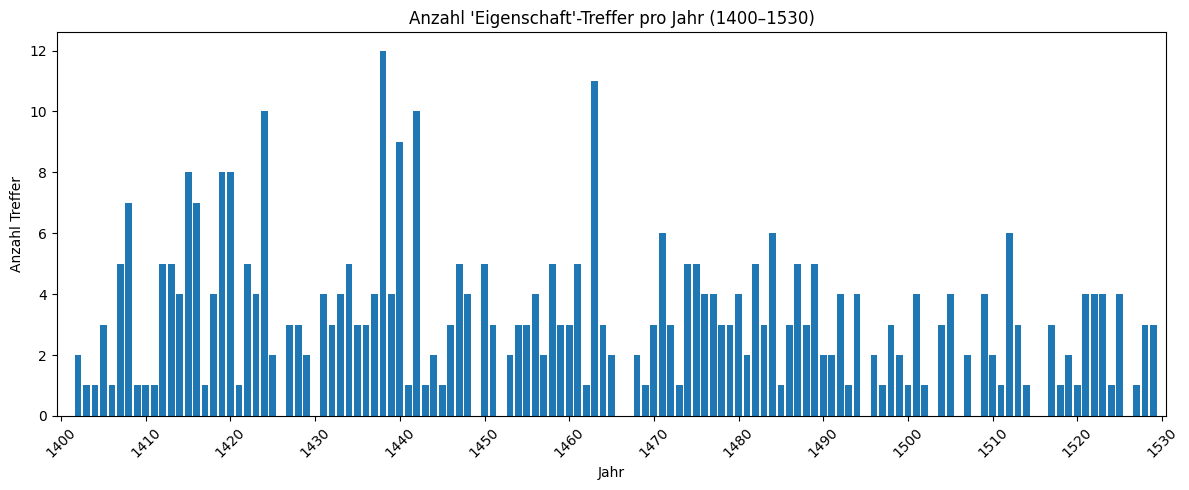

In [23]:
import matplotlib.pyplot as plt

yearmin = 1400
yearmax = 1530

# Nur Datensätze mit cause == "Eigenschaft"
eigenschaft_df = zinsen_personen_df[
    zinsen_personen_df["cause"] == "Eigenschaft"
].copy()

eigenschaft_df["year"] = eigenschaft_df["year"].astype(int)

# Jahresbereich filtern
eigenschaft_df = eigenschaft_df[
    (eigenschaft_df["year"] >= yearmin) &
    (eigenschaft_df["year"] <= yearmax)
]

# Treffer pro Jahr zählen
jahres_counts = (
    eigenschaft_df["year"]
    .value_counts()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 5))
plt.bar(jahres_counts.index, jahres_counts.values, width=0.8)

# Nur alle 10 Jahre als Tick anzeigen
plt.xticks(range(yearmin, yearmax + 1, 10), rotation=45)

plt.xlim(yearmin - 0.5, yearmax + 0.5)
plt.xlabel("Jahr")
plt.ylabel("Anzahl Treffer")
plt.title(f"Anzahl 'Eigenschaft'-Treffer pro Jahr ({yearmin}–{yearmax})")

plt.tight_layout()
plt.show()

# Genaue Betrachtung der Renten

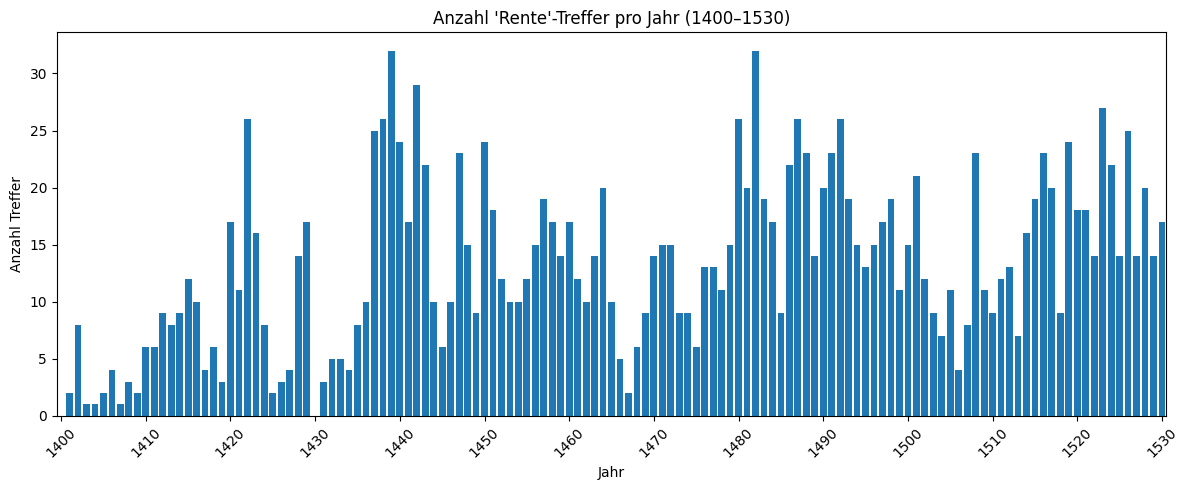

In [41]:
import matplotlib.pyplot as plt

yearmin = 1400
yearmax = 1530

# Nur Datensätze mit cause == "Rente"
Rente_df = zinsen_personen_df[
    zinsen_personen_df["cause"] == "Rente"
].copy()

Rente_df["year"] = Rente_df["year"].astype(int)

# Jahresbereich filtern
Rente_df = Rente_df[
    (Rente_df["year"] >= yearmin) &
    (Rente_df["year"] <= yearmax)
]

# Treffer pro Jahr zählen
jahres_counts = (
    Rente_df["year"]
    .value_counts()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 5))
plt.bar(jahres_counts.index, jahres_counts.values, width=0.8)

# Nur alle 10 Jahre als Tick anzeigen
plt.xticks(range(yearmin, yearmax + 1, 10), rotation=45)

plt.xlim(yearmin - 0.5, yearmax + 0.5)
plt.xlabel("Jahr")
plt.ylabel("Anzahl Treffer")
plt.title(f"Anzahl 'Rente'-Treffer pro Jahr ({yearmin}–{yearmax})")

plt.tight_layout()
plt.show()

# Genaue Betrachtung der Weisung

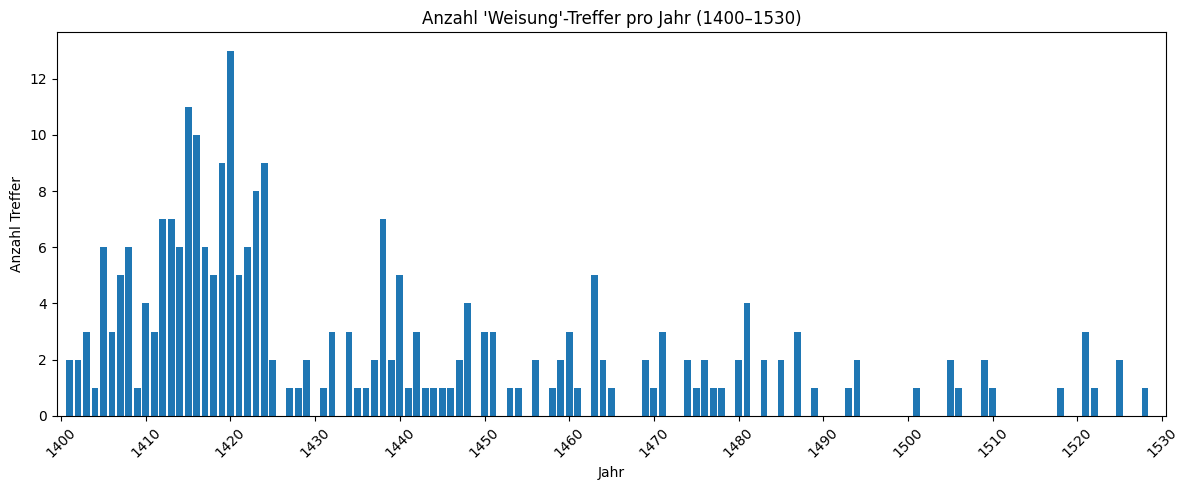

In [25]:
import matplotlib.pyplot as plt

yearmin = 1400
yearmax = 1530

# Nur Datensätze mit cause == "Weisung"
Weisung_df = zinsen_personen_df[
    zinsen_personen_df["cause"] == "Weisung"
].copy()

Weisung_df["year"] = Weisung_df["year"].astype(int)

# Jahresbereich filtern
Weisung_df = Weisung_df[
    (Weisung_df["year"] >= yearmin) &
    (Weisung_df["year"] <= yearmax)
]

# Treffer pro Jahr zählen
jahres_counts = (
    Weisung_df["year"]
    .value_counts()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 5))
plt.bar(jahres_counts.index, jahres_counts.values, width=0.8)

# Nur alle 10 Jahre als Tick anzeigen
plt.xticks(range(yearmin, yearmax + 1, 10), rotation=45)

plt.xlim(yearmin - 0.5, yearmax + 0.5)
plt.xlabel("Jahr")
plt.ylabel("Anzahl Treffer")
plt.title(f"Anzahl 'Weisung'-Treffer pro Jahr ({yearmin}–{yearmax})")

plt.tight_layout()
plt.show()

# Genaue Betrachtung der Ehrschatz

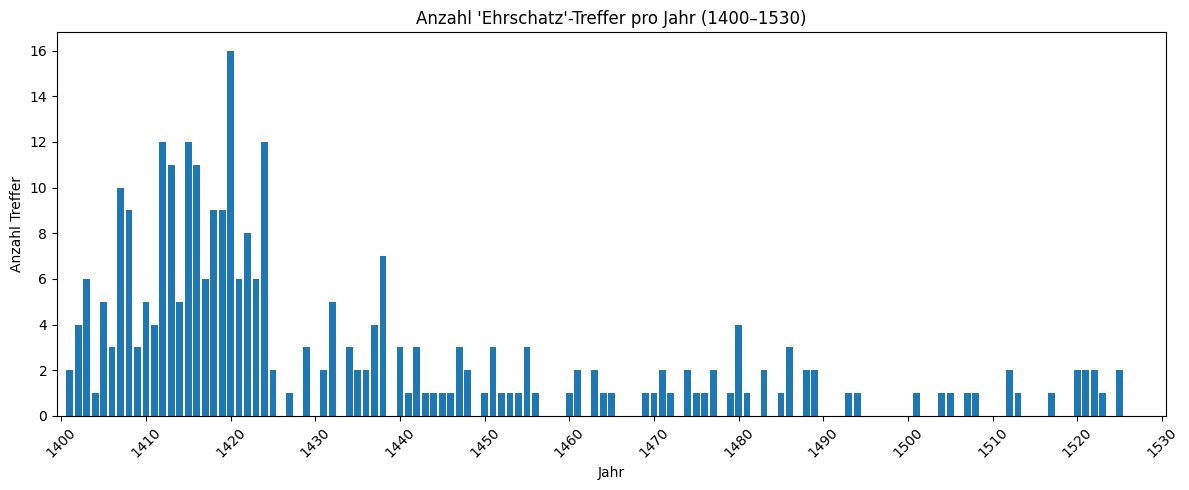

In [26]:
import matplotlib.pyplot as plt

yearmin = 1400
yearmax = 1530

# Nur Datensätze mit cause == "Ehrschatz"
eigenschaft_df = zinsen_personen_df[
    zinsen_personen_df["cause"] == "Ehrschatz"
].copy()

eigenschaft_df["year"] = eigenschaft_df["year"].astype(int)

# Jahresbereich filtern
eigenschaft_df = eigenschaft_df[
    (eigenschaft_df["year"] >= yearmin) &
    (eigenschaft_df["year"] <= yearmax)
]

# Treffer pro Jahr zählen
jahres_counts = (
    eigenschaft_df["year"]
    .value_counts()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 5))
plt.bar(jahres_counts.index, jahres_counts.values, width=0.8)

# Nur alle 10 Jahre als Tick anzeigen
plt.xticks(range(yearmin, yearmax + 1, 10), rotation=45)

plt.xlim(yearmin - 0.5, yearmax + 0.5)
plt.xlabel("Jahr")
plt.ylabel("Anzahl Treffer")
plt.title(f"Anzahl 'Ehrschatz'-Treffer pro Jahr ({yearmin}–{yearmax})")

plt.tight_layout()
plt.show()

# 4. Dauer existierender Zinsen 

Anhand von Organisationszinsen ermittelt

### Durchschnittliche Zeitspanne Eigenschaft

Änderungen, die im oberen Teil dieses Notebooks ausgeführt wurden (Vorbereitung) müssen ausgeführt werden, damit sie in die kommenden Berechnungen miteinfliessen

In [27]:
zinszeitspanneorgs_eigenschaft_df = rentsall_korrektur_df.copy()

In [28]:
eigenschaft_df = zinszeitspanneorgs_eigenschaft_df[
    zinszeitspanneorgs_eigenschaft_df["cause"] == "Eigenschaft"
].copy()

In [29]:
eigenschaft_df["year"] = pd.to_numeric(eigenschaft_df["year"], errors="coerce")
eigenschaft_df["interest_pd"] = pd.to_numeric(eigenschaft_df["interest_pd"], errors="coerce")

In [30]:
def aggregate_eigenschaft(group):
    # Nach Jahr sortieren
    group = group.sort_values("year")
    
    min_year = group["year"].min()
    max_year = group["year"].max()
    
    # Zeitspanne
    zeitspanne = f"{int(min_year)}-{int(max_year)}"
    
    # inyears
    inyears = 1 if len(group) == 1 else int(max_year - min_year)
    
    # Interest first and last
    first_interest = group.iloc[0]["interest_pd"]
    last_interest = group.iloc[-1]["interest_pd"]
    
    interest_str = f"{first_interest}, {last_interest}"
    
    # Zusätzliche Spalten aufnehmen
    collection_street = group["collection_street"].iloc[0]
    collection_house = group["collection_house"].iloc[0]
    collection_coord_x = group["collection_coord_x"].iloc[0]
    collection_coord_y = group["collection_coord_y"].iloc[0]
    text = group["text"].iloc[0]
    
    return pd.Series({
        "zeitspanne_eigenschaft": zeitspanne,
        "inyears_eigenschaft": inyears,
        "interestvaluefirstandlast_eigenschaft": interest_str,
        "collection_street": collection_street,
        "collection_house": collection_house,
        "collection_coord_x": collection_coord_x,
        "collection_coord_y": collection_coord_y,
        "text": text
    })

# Aggregieren
aggregated_df = (
    eigenschaft_df
    .groupby(["dossier", "claimantOrg", "cause"], dropna=False)
    .apply(aggregate_eigenschaft)
    .reset_index()
)

/var/folders/n4/t9gk6y5969s0ptnyp8q2q_th0000gq/T/ipykernel_19635/3592377128.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_eigenschaft)


In [31]:
zinszeitspanneorgs_eigenschaft_df = aggregated_df.copy()

In [32]:
zinszeitspanneorgs_eigenschaft_df

,dossier,claimantOrg,cause,zeitspanne_eigenschaft,inyears_eigenschaft,interestvaluefirstandlast_eigenschaft,collection_street,collection_house,collection_coord_x,collection_coord_y,text
0,HGB_1_001_027,Bruderschaft St. Johann,Eigenschaft,1482-1502,20,"0.1, 0.25",Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,Burkhart Segenser Schultheis als Vogt ư Gwalth...
1,HGB_1_001_036,no_org,Eigenschaft,1494-1494,1,"0.25, 0.25",Aeschengraben,Aeschengraben 32,2.611581e+06,1.266602e+06,"Lienhart Gernler der seyler, verkauft an Ulric..."
2,HGB_1_001_038,NaN,Eigenschaft,1487-1492,5,"0.125, 0.125",Aeschengraben,Aeschengraben 34,2.611568e+06,1.266590e+06,Klaus Kesler von Nuwenburg ư seine Frau Elsin\...
3,HGB_1_001_040,Barfüsserkloster,Eigenschaft,1438-1438,1,"1.025, 1.025",Aeschengraben,Aeschengraben 48,2.611475e+06,1.266539e+06,gend ze kaufen Clara klein Rutschlis von Rynow...
4,HGB_1_002_025,Bruderschaft St. Johann,Eigenschaft,1520-1520,1,"0.55, 0.55",Aeschenvorstadt,Aeschenvorstadt 7,2.611588e+06,1.266989e+06,Johann Raman von Wenegken der artzner Doctor S...
...,...,...,...,...,...,...,...,...,...,...,...
2636,HGB_1_229_040,Heiliggeist-Spital,Eigenschaft,1464-1479,15,"0.0, 3.0",Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,Official-Urkunde.\nMaus Blattner der Goltstahe...
2637,HGB_1_229_040,St. Alban,Eigenschaft,1566-1566,1,"0.0749996, 0.0749996",Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,"Mr. Ulrich Brateler des Raths, und seine Frau ..."
2638,HGB_1_229_042,Hochstift,Eigenschaft,1493-1516,23,"0.8500000000000001, 0.6000000000000001",Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM..."
2639,HGB_1_229_043,NaN,Eigenschaft,1439-1447,8,"2.0, 4.0",Weisse Gasse / Weissegasse,Weisse Gasse Theil von 28 neben Barfüsserplatz 4,2.611362e+06,1.267166e+06,gend ze kaufen Ulrich von rättwilr ze Basel wo...


In [33]:
# 1. Filtern: Nur Werte nehmen, die ungleich 1 sind
# (Oder > 1, falls es keine negativen Werte gibt)
filtered_values = zinszeitspanneorgs_eigenschaft_df.loc[
    zinszeitspanneorgs_eigenschaft_df['inyears_eigenschaft'] > 1, 
    'inyears_eigenschaft'
]

# 2. Berechnung von Mittelwert und Median
mean_val = filtered_values.mean()
median_val = filtered_values.median()

# 3. Ergebnis ausgeben
print(f"Statistik für 'inyears_eigenschaft' (ohne den Wert 1):")
print(f"---")
print(f"Mittelwert: {mean_val:.2f} Jahre")
print(f"Median:     {median_val:.2f} Jahre")
print(f"Anzahl der berücksichtigten Datensätze: {len(filtered_values)}")

Statistik für 'inyears_eigenschaft' (ohne den Wert 1):
---
Mittelwert: 51.18 Jahre
Median:     41.00 Jahre
Anzahl der berücksichtigten Datensätze: 879


### Durchschnittliche Zeitspanne Rente

In [34]:
zinszeitspanneorgs_rente_df = rentsall_korrektur_df.copy()

In [35]:
zinszeitspanneorgs_rente_df

,collection_id,collection_street,collection_house,collection_coord_x,collection_coord_y,id,dossier,pages,year,text,...,redeemable_amount,redeemable_amount_norm,redeemable_amount_pd,dues_text,renteabloesig,hauptgutabloesig,beneficiary_per,lat,lon,fuzzy_score
0,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,NaN,47.550546,7.593183,50.0
1,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,38670,HGB_1_001_027,10,1502.0,"Conrat Gilgenzwig diser zit elts, des gotshus ...",...,NaN,NaN,NaN,zinst der Garten jährl von eig . 5sh . s . Joh...,NaN,NaN,Frau Elsy Lutpoltin,47.550546,7.593183,50.0
2,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,70628,HGB_1_001_027,5,1421.0,gend ze kaufen Hauss am Steg von Westhusen\nun...,...,NaN,NaN,NaN,ist erb von der brudersch . zes . Johans uf Bu...,NaN,NaN,NaN,47.550546,7.593183,50.0
3,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,90559,HGB_1_001_027,6,1424.0,gend ze kaufen Henman Weyblinger der schnider\...,...,NaN,NaN,NaN,dem darab gand 4sh . u . och zem teil vor Henn...,NaN,NaN,dem,47.550546,7.593183,50.0
4,HGB_1_001_027,Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,42268,HGB_1_001_027,9,1482.0,Burkhart Segenser Schultheis als Vogt ư Gwalth...,...,NaN,NaN,NaN,zinset von eig . 2sh . s . Joh . Brudi uf Burg...,NaN,NaN,NaN,47.550546,7.593183,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18521,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708,40.0
18522,HGB_1_229_040,Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,81262,HGB_1_229_040,9,1464.0,Official-Urkunde.\nMaus Blattner der Goltstahe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555409,7.589708,40.0
18523,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575,50.0
18524,HGB_1_229_042,Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,45961,HGB_1_229_042,12,1493.0,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.555116,7.589575,50.0


In [36]:
rente_df = zinszeitspanneorgs_rente_df[
    zinszeitspanneorgs_rente_df["cause"] == "Rente"
].copy()

In [37]:
import pandas as pd

rente_df["year"] = pd.to_numeric(rente_df["year"], errors="coerce")
rente_df["interest_pd"] = pd.to_numeric(rente_df["interest_pd"], errors="coerce")

In [38]:
def aggregate_rente(group):
    # Nach Jahr sortieren
    group = group.sort_values("year")
    
    min_year = group["year"].min()
    max_year = group["year"].max()
    
    # Zeitspanne
    zeitspanne = f"{int(min_year)}-{int(max_year)}"
    
    # inyears
    inyears = 1 if len(group) == 1 else int(max_year - min_year)
    
    # Interest first and last
    first_interest = group.iloc[0]["interest_pd"]
    last_interest = group.iloc[-1]["interest_pd"]
    
    interest_str = f"{first_interest}, {last_interest}"
    
    # Zusätzliche Spalten aufnehmen
    collection_street = group["collection_street"].iloc[0]
    collection_house = group["collection_house"].iloc[0]
    collection_coord_x = group["collection_coord_x"].iloc[0]
    collection_coord_y = group["collection_coord_y"].iloc[0]
    text = group["text"].iloc[0]
    
    return pd.Series({
        "zeitspanne_rente": zeitspanne,
        "inyears_rente": inyears,
        "interestvaluefirstandlast_rente": interest_str,
        "collection_street": collection_street,
        "collection_house": collection_house,
        "collection_coord_x": collection_coord_x,
        "collection_coord_y": collection_coord_y,
        "text": text
    })

# Aggregieren
aggregated_df = (
    rente_df
    .groupby(["dossier", "claimantOrg", "cause"], dropna=False)
    .apply(aggregate_rente)
    .reset_index()
)

/var/folders/n4/t9gk6y5969s0ptnyp8q2q_th0000gq/T/ipykernel_19635/726421233.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_rente)


In [39]:
zinszeitspanneorgs_rente_df = aggregated_df.copy()

In [40]:
zinszeitspanneorgs_rente_df

,dossier,claimantOrg,cause,zeitspanne_rente,inyears_rente,interestvaluefirstandlast_rente,collection_street,collection_house,collection_coord_x,collection_coord_y,text
0,HGB_1_001_027,Gotteshaus,Rente,1586-1586,1,"nan, nan",Aeschengraben,Aeschengraben 20,2.611635e+06,1.266659e+06,"Gross Basel.\nFriderich Werdenberg, des Raths ..."
1,HGB_1_001_034,NaN,Rente,1528-1528,1,"6.25, 6.25",Aeschengraben,Aeschengraben 30,2.611587e+06,1.266613e+06,Ulrich Appentzeller under der Gartner und sein...
2,HGB_1_001_036,NaN,Rente,1494-1494,1,"1.0, 1.0",Aeschengraben,Aeschengraben 32,2.611581e+06,1.266602e+06,Hanns Gernler der Seiler als Hptverk. dies Lie...
3,HGB_1_001_039,Predigerkloster,Rente,1415-1415,1,"nan, nan",Aeschengraben,Aeschengraben 36-46,2.611376e+06,1.266486e+06,Item da kouffte Peter Schaltenbrand die gefrön...
4,HGB_1_002_023,Städtisches Almosen,Rente,1552-1552,1,"4.0, 4.0",Aeschenvorstadt,Aeschenvorstadt 3,2.611571e+06,1.267011e+06,"Christiana Für, Hanns Füren des Haffners sel. ..."
...,...,...,...,...,...,...,...,...,...,...,...
2999,HGB_1_229_040,Münsterbau,Rente,1464-1464,1,"2.3, 2.3",Weisse Gasse / Weissegasse,Weisse Gasse 26,2.611372e+06,1.267199e+06,Official-Urkunde.\nMaus Blattner der Goltstahe...
3000,HGB_1_229_042,NaN,Rente,1493-1516,23,"0.05, 0.6000000000000001",Weisse Gasse / Weissegasse,"Weisse Gasse Theil von 28, Mitte",2.611362e+06,1.267166e+06,"Berbelin Rümliker verkauft an Ennelin, wyl.\nM..."
3001,HGB_1_229_043,NaN,Rente,1439-1560,121,"2.0, 2.0",Weisse Gasse / Weissegasse,Weisse Gasse Theil von 28 neben Barfüsserplatz 4,2.611362e+06,1.267166e+06,git ze kaufen Ulrich von Rotwilr der zumberman...
3002,HGB_1_229_044,Altar St. Verena im Münster,Rente,1527-1527,1,"1.0, 1.0",Weisse Gasse / Weissegasse,Weisse Gasse Theil von 28 neben 26 und Mitte,2.611375e+06,1.267193e+06,Heinrich Petri als gwalthaber Adam Petri des t...


In [42]:
# 1. Filtern: 
# Bedingung A: inyears_rente > 1
# Bedingung B: claimantOrg darf nicht leer sein (notna)
filtered_values = zinszeitspanneorgs_rente_df.loc[
    (zinszeitspanneorgs_rente_df['inyears_rente'] > 1) & 
    (zinszeitspanneorgs_rente_df['claimantOrg'].notna()), 
    'inyears_rente'
]

# 2. Berechnung von Mittelwert und Median
mean_val = filtered_values.mean()
median_val = filtered_values.median()

# 3. Ergebnis ausgeben
print(f"Statistik für 'inyears_rente' (ohne Wert 1 & ohne fehlende Organisation):")
print(f"---")
print(f"Mittelwert: {mean_val:.2f} Jahre")
print(f"Median:     {median_val:.2f} Jahre")
print(f"Anzahl der berücksichtigten Datensätze: {len(filtered_values)}")

Statistik für 'inyears_rente' (ohne Wert 1 & ohne fehlende Organisation):
---
Mittelwert: 37.04 Jahre
Median:     24.00 Jahre
Anzahl der berücksichtigten Datensätze: 183
